In [2]:
#!/usr/bin/env python
# coding: utf-8

import os, sys, pickle
import jax, jaxlib
import jax.numpy as jnp
import matplotlib.pyplot as plt
import scipy
from scipy.io import loadmat
import numpy as np

import flax
from flax import linen as nn
import optax
from sklearn.model_selection import train_test_split
from typing import Callable, Sequence
import time

from models import branch_net, trunk_net


seed = 42
print("Seed: ", seed)
np.random.seed(seed)
key = jax.random.PRNGKey(seed)


base_path = "/home/dnayak2/data_sgoswam4/Dibya/Datasets/1D_KS/"
outputs = (loadmat(os.path.join(base_path, "KS_simple.mat"))["u_out"])[:3000]

Ns, Nt, Nx = outputs.shape
print(f"Ns: {Ns}, Nt: {Nt}, Nx: {Nx}")


#Creating the input and output training data
tt = int(Nt//2)
init_timestep = 0
end_timestep = tt
dt = (1-0)/(Nt-1)
print(f"Computed dt: {dt}")

input_data_NN = outputs[:,init_timestep,:]
output_data_NN = outputs[:,init_timestep+1,:]

for i in range(init_timestep+1, end_timestep):
    input_data_NN = jnp.vstack((input_data_NN, outputs[:,i,:]))
    output_data_NN = jnp.vstack((output_data_NN, outputs[:,i+1,:]))

print(input_data_NN.shape, output_data_NN.shape)


input_data_NN_train, input_data_NN_test, output_data_NN_train, output_data_NN_test = \
                        train_test_split(input_data_NN, output_data_NN, test_size = 0.2, random_state = 42)
print(input_data_NN_train.shape, input_data_NN_test.shape, output_data_NN_train.shape, output_data_NN_test.shape)


del input_data_NN, output_data_NN


def add_fourier_features(inputs, num_frequencies=10, max_freq=10):
    x = inputs[:, 0:1]
    freqs = jnp.pi * jnp.linspace(1, max_freq, num_frequencies).reshape(1, -1)
    x_feat = jnp.concatenate([jnp.sin(freqs * x), jnp.cos(freqs * x)], axis=-1)
    
    return jnp.concatenate([inputs, x_feat], axis=-1)


class DeepONet(nn.Module):

    branch_net_config: Sequence[int]
    trunk_net_config: Sequence[int]
    use_Fourier_feat: bool = True

    def setup(self):
        self.branch_net = branch_net(self.branch_net_config, activation=nn.activation.tanh)
        self.trunk_net = trunk_net(self.trunk_net_config, activation=jnp.sin)

    def __call__(self, x_branch, x_trunk):
        
        if self.use_Fourier_feat:
            #Encode x_trunk into fourier features
            x_trunk = add_fourier_features(x_trunk)
        
        #Vectorize over multiple samples of input functions
        branch_outputs = self.branch_net(x_branch)
        
        #Vectorize over multiple query points
        trunk_outputs = self.trunk_net(x_trunk)
        
        inner_product = jnp.einsum('ik,jk->ij', branch_outputs, trunk_outputs)

        return inner_product


#Form branch and trunk inputs train
grid = jnp.linspace(0, 1, Nx)[:,jnp.newaxis]
branch_inputs_train = input_data_NN_train
trunk_inputs_train = grid
outputs_train = output_data_NN_train
branch_inputs_train.shape, trunk_inputs_train.shape, outputs_train.shape


#For branch and trunk inputs test
branch_inputs_test = input_data_NN_test
trunk_inputs_test = grid
outputs_test = output_data_NN_test

branch_inputs_test.shape, trunk_inputs_test.shape, outputs_test.shape


#DeepONet settings
num_sensor_locations = branch_inputs_train.shape[1]
num_query_locations = 1
latent_vector_size = 100

branch_network_layer_sizes = [128]*7 + [latent_vector_size]
trunk_network_layer_sizes = [128]*7 + [latent_vector_size]

model = DeepONet(branch_network_layer_sizes, trunk_network_layer_sizes)

model_fn = jax.jit(model.apply)


def save_model_params(params, path, filename):
    
    #Create output directory for saving model params
    if not os.path.exists(path):
        os.makedirs(path)
    
    save_path = os.path.join(path, filename)
    with open(save_path, 'wb') as f:
        pickle.dump(params, f)

def load_model_params(path, filename):
    load_path = os.path.join(path, filename)
    with open(load_path, 'rb') as f:
        params = pickle.load(f)
    return params


@jax.jit
def loss_fn(params, branch_inputs, trunk_inputs, gt_outputs, dt):
    
    u_curr = branch_inputs  # Current state input (e.g., u(t))
    u_next = gt_outputs     # Ground truth next state (e.g., u(t+1))

    # Predict the system dynamics (u_dot) at the current state using the model
    u_dot = model_fn(params, u_curr, trunk_inputs)  # Model's predicted rate of change

    # Implementing the 4th-order Runge-Kutta (RK4) time-stepping method
    k1 = u_dot
    k2 = model_fn(params, u_curr + 0.5 * dt * k1, trunk_inputs)
    k3 = model_fn(params, u_curr + 0.5 * dt * k2, trunk_inputs)
    k4 = model_fn(params, u_curr + dt * k3, trunk_inputs)
    
    # Calculate the next state using RK4
    u_pred_next = u_curr + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)

    # Compute the Mean Squared Error loss between the predicted and ground truth next states
    mse_loss = jnp.mean(jnp.square(u_pred_next - u_next))
    
    return mse_loss


@jax.jit
def update(params, branch_inputs, trunk_inputs, gt_outputs, opt_state, dt):
    loss, grads = jax.value_and_grad(loss_fn)(params, branch_inputs, trunk_inputs, gt_outputs, dt)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


# Initialize model parameters
params = model.init(key, branch_inputs_train[0:1], trunk_inputs_train[0:1])

# # Optimizer setup
lr_scheduler = optax.schedules.exponential_decay(init_value=1e-3, transition_steps=5000, decay_rate=0.95)
optimizer = optax.adamw(learning_rate=lr_scheduler, weight_decay=1e-4)
opt_state = optimizer.init(params)

training_loss_history = []
test_loss_history = []
num_epochs = int(1.5e5)
batch_size = 128

min_test_loss = jnp.inf

filepath = 'DeepONet_NODE'
filename = 'model_params_best.pkl'

# for epoch in range(num_epochs):

#     #Perform mini-batching
#     shuffled_indices = jax.random.permutation(jax.random.PRNGKey(epoch), branch_inputs_train.shape[0])
#     batch_indices = shuffled_indices[:batch_size]

#     branch_inputs_train_batch = branch_inputs_train[batch_indices]
#     outputs_train_batch = outputs_train[batch_indices]

#     # Update the parameters and optimizer state
#     params, opt_state, loss = update(
#         params=params,
#         branch_inputs=branch_inputs_train_batch,
#         trunk_inputs=trunk_inputs_train,
#         gt_outputs=outputs_train_batch,
#         opt_state=opt_state,
#         dt=dt
#     )

#     training_loss_history.append(loss)
    
#     #Do predictions on the test data simultaneously
#     test_mse_loss = loss_fn(params = params, 
#                             branch_inputs = branch_inputs_test, 
#                             trunk_inputs = trunk_inputs_test, 
#                             gt_outputs = outputs_test,
#                             dt=dt)
#     test_loss_history.append(test_mse_loss)
    
#     #Save the params of the best model encountered till now
#     if test_mse_loss < min_test_loss:
#         best_params = params
#         save_model_params(best_params, path = filepath, filename = filename)
#         min_test_loss = test_mse_loss
    
#     #Print the train and test loss history every 1000 epochs
#     if epoch % 1000 == 0:
#         print(f"Epoch: {epoch}, train_loss: {loss}, test_loss: {test_mse_loss}, best_test_loss: {min_test_loss}")


# plt.figure(dpi = 130)
# plt.semilogy(np.arange(epoch+1), training_loss_history, label = "Train loss")
# plt.semilogy(np.arange(epoch+1), test_loss_history, label = "Test loss")

# plt.xlabel("Epochs")
# plt.ylabel("Loss")

# plt.tick_params(which = 'major', axis = 'both', direction = 'in', length = 6)
# plt.tick_params(which = 'minor', axis = 'both', direction = 'in', length = 3.5)
# plt.minorticks_on()

# plt.grid(alpha = 0.3)
# plt.legend(loc = 'best')

# save = True
# if save:
#     plt.savefig(filepath + "/loss_plot.jpeg", dpi = 800)
# plt.show()


# #Save the loss arrays
# if True:
#     np.save(filepath + "/Train_loss.npy",training_loss_history)
#     np.save(filepath + "/Test_loss.npy",test_loss_history)


# @jax.jit
def inference_ab2_am3(u_curr, u_prev, trunk_inputs_test, dt):
    
    # Step 1: Apply the predictor (Adams-Bashforth) using u_curr and u_prev
    u_dot_curr = model_fn(best_params, u_curr, trunk_inputs_test)  # Predict the rate of change at u_curr
    u_dot_prev = model_fn(best_params, u_prev, trunk_inputs_test)  # Predict the rate of change at u_prev
    
    # Adams-Bashforth predictor (using previous two points)
    u_pred = u_curr + dt * (1.5 * u_dot_curr - 0.5 * u_dot_prev)
    
    # Step 2: Apply the corrector (Adams-Moulton) using the predicted u_pred
    u_dot_pred = model_fn(best_params, u_pred, trunk_inputs_test)  # Predict the rate of change at u_pred
    
    # Adams-Moulton corrector (refine the prediction using u_pred)
    u_next = u_curr + dt * (5/12 * u_dot_pred + 8/12 * u_dot_curr - 1/12 * u_dot_prev)
    
    return u_next


# @jax.jit
def inference_ab3_am3(u_curr, u_prev1, u_prev2, prev3, trunk_inputs_test, dt):
    
    #Predictor: AB3 (order 3)
    f_n = model_fn(best_params, u_curr, trunk_inputs_test)
    f_n_1 = model_fn(best_params, u_prev1, trunk_inputs_test)
    f_n_2 = model_fn(best_params, u_prev2, trunk_inputs_test)
    
    u_pred = u_curr + (dt/12) * (23*f_n - 16*f_n_1 + 5*f_n_2)
    
    #Corrector: AM3 (order 3)
    f_pred = model_fn(best_params, u_pred, trunk_inputs_test)
    u_next = u_curr + (dt/24) * (9*f_pred + 19*f_n - 5*f_n_1 + f_n_2)

    return u_next


# @jax.jit
def inference_rk(u_curr, trunk_inputs_test, dt):
    
    # Predict the system dynamics (u_dot) at the current state using the model
    u_dot = model_fn(params, u_curr, trunk_inputs_test)  # Model's predicted rate of change

    # Implementing the 4th-order Runge-Kutta (RK4) time-stepping method
    k1 = u_dot
    k2 = model_fn(params, u_curr + 0.5 * dt * k1, trunk_inputs_test)
    k3 = model_fn(params, u_curr + 0.5 * dt * k2, trunk_inputs_test)
    k4 = model_fn(params, u_curr + dt * k3, trunk_inputs_test)
    
    # Calculate the next state using RK4
    u_pred_next = u_curr + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    
    return u_pred_next


def run_inference(initial_u, trunk_inputs_test, n_steps, method, dt):
    print(f"Method being used: {method}")
    print("dt_val: ",dt)
    u_states = np.zeros(shape = (initial_u.shape[0], n_steps, initial_u.shape[1]))  # List to store the states over time
    u_states[:, 0, :] = initial_u

    # Initialize the previous states (this could be your u_0 and u_1, etc.)
    u_prev2 = initial_u  # Set the previous-to-previous state to initial state
    u_prev1 = initial_u  # Set the previous state to initial state
    u_curr = initial_u  # Set the current state to initial state

    # For AB3 method, we need a special warm start for the first two steps
    if method == "AB3":
        
        for i in range(1, n_steps):
            print(f"Computed for {i}")
            if i < 2:
                u_next = inference_ab2_am3(u_curr, u_prev1, trunk_inputs_test)
            else:
                u_next = inference_ab3_am3(u_curr, u_prev1, u_prev2, trunk_inputs_test)
            u_states[:, i, :] = u_next
            
            u_prev2 = u_prev1
            u_prev1 = u_curr
            u_curr = u_next

    elif method == "AB":
        for i in range(1, n_steps):
            # Perform inference step using the Adams-Bashforth method
            u_next = inference_ab2_am3(u_curr, u_prev1, trunk_inputs_test, dt)
            u_states[:, i, :] = u_next

            # Update previous and current states for the next step
            u_prev1 = u_curr
            u_curr = u_next

    elif method == "RK":
        for i in range(1, n_steps):
            # Perform inference step using the RK4 method
            u_next = inference_rk(u_curr, trunk_inputs_test, dt)
            u_states[:, i, :] = u_next

            # Update the current state for the next step
            u_curr = u_next

    else:
        raise ValueError(f"Unknown method: {method}")

    return u_states


# Load the best model parameters
best_params = load_model_params(path=filepath, filename=filename)
outputs = (loadmat(os.path.join(base_path, "KS_simple.mat"))["u_out"])[:3000]

Ns, Nt, Nx = outputs.shape
u_curr = outputs[:, 0, :]

method = "AB"

n_steps1 = Nt
dt1 = (1-0)/(n_steps1-1)
u_pred_dt_1 = run_inference(u_curr, trunk_inputs_test, n_steps=n_steps1, method=method, dt=dt1)

n_steps2 = Nt*10
dt2 = (1-0)/(n_steps2-1)
u_pred_dt_2 = run_inference(u_curr, trunk_inputs_test, n_steps=n_steps2, method=method, dt=dt2)

n_steps3 = int(Nt/10)
dt3 = (1-0)/(n_steps3-1)
u_pred_dt_3 = run_inference(u_curr, trunk_inputs_test, n_steps=n_steps3, method=method, dt=dt3)

Seed:  42
Ns: 3000, Nt: 300, Nx: 128
Computed dt: 0.0033444816053511705
(450000, 128) (450000, 128)
(360000, 128) (90000, 128) (360000, 128) (90000, 128)
Method being used: AB
dt_val:  0.0033444816053511705
Method being used: AB
dt_val:  0.00033344448149383126
Method being used: AB
dt_val:  0.034482758620689655


In [4]:
u_pred_dt_1.shape, u_pred_dt_2.shape, u_pred_dt_3.shape

((3000, 300, 128), (3000, 3000, 128), (3000, 30, 128))

In [6]:
#dt = 1e-2

err_dt_1 = []
for t in range(u_pred_dt_1.shape[1]):
    err_val = np.linalg.norm(u_pred_dt_1[:,t,:] - outputs[:,t,:])/np.linalg.norm(outputs[:,t,:])
    err_dt_1.append(err_val)
len(err_dt_1)

300

In [8]:
#dt = 1e-3

err_dt_2 = []
u_pred_dt_2_aligned = u_pred_dt_2[:,::10,:]
for t in range(outputs.shape[1]):
    err_val = np.linalg.norm(u_pred_dt_2_aligned[:,t,:] - outputs[:,t,:])/np.linalg.norm(outputs[:,t,:])
    err_dt_2.append(err_val)
len(err_dt_2)

300

In [9]:
#dt = 1e-1

err_dt_3 = []
outputs_aligned = outputs[:, ::10, :]
for t in range(u_pred_dt_3.shape[1]):
    err_val = np.linalg.norm(u_pred_dt_3[:,t,:] - outputs_aligned[:,t,:])/np.linalg.norm(outputs_aligned[:,t,:])
    err_dt_3.append(err_val)
len(err_dt_3)

30

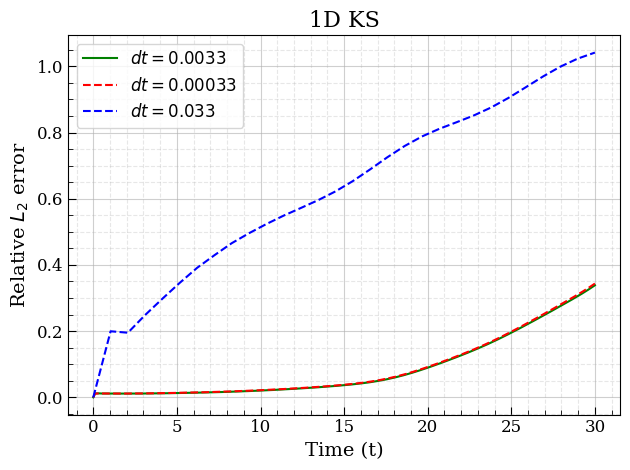

In [11]:
plt.rcParams['font.family'] = 'Serif'

plt.plot(np.linspace(0,30,len(err_dt_1)), err_dt_1, label="$dt=0.0033$", color = "green")
plt.plot(np.linspace(0,30,len(err_dt_2)), err_dt_2, label="$dt=0.00033$", color = "red", linestyle="dashed")
plt.plot(np.linspace(0,30,len(err_dt_3)), err_dt_3, label="$dt=0.033$", color = "blue", linestyle="dashed")

plt.xlabel("Time (t)", fontsize=14)
plt.ylabel("Relative $L_2$ error", fontsize=14)
plt.title("1D KS", fontsize=16)

plt.xticks(fontsize = 12)
plt.yticks(fontsize = 12)

plt.tick_params(axis = "both", which = "major", length = 6, direction = "in")
plt.tick_params(axis = "both", which = "minor", length = 3.5, direction = "in")
plt.minorticks_on()

plt.grid(which="major", axis="both", alpha=0.6, linestyle='-')
plt.grid(which="minor", axis="both", alpha=0.3, linestyle='--')

plt.legend(fontsize = 12)
plt.tight_layout()

plt.savefig("Error_acc_TI_DON_different_dt_1D_KS.jpeg", dpi=200)
plt.show()